# Choropleth Maps — Current High vs Predicted High Districts per Crop

For each crop this notebook produces a map of India at the district level showing three categories:

| Category | Colour | Meaning |
|---|---|---|
| **Current High** | Dark green | District is in the training data and classified as High yield |
| **Predicted High** | Gold / amber | District has no crop data but models unanimously predict High (our policy targets) |
| **Other / No data** | Light grey | District is in neither category for this crop |

Maps are saved as PNG files in `choropleth_maps/<crop_name>.png`.

## 1 — Imports and configuration

In [22]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")
os.makedirs("choropleth_maps", exist_ok=True)

# ── Paths ──────────────────────────────────────────────────────────────────
GEOJSON_URL      = "https://raw.githubusercontent.com/saketlab/bharatviz/refs/heads/main/public/India_LGD_districts.geojson"
CLASSIFIED_DIR   = "clean_crop_contribution_data/aggregated_data/kmeans_classes"
HIGH_PAIRS_CSV   = "underutilised_districts/high_potential_pairs.csv"

# ── Parameters ─────────────────────────────────────────────────────────────
HIGH_CLASS  = "High"    # label used for high-yield class (groundnut uses 'Medium')
MIN_ROWS    = 200       # same gate as training
FIG_DPI     = 150

# ── Colour palette ─────────────────────────────────────────────────────────
COLOR_CURRENT   = "#1a7a3e"   # dark green  — current High districts
COLOR_PREDICTED = "#f5a623"   # amber/gold  — predicted High districts
COLOR_OTHER     = "#e8e8e8"   # light grey  — everything else
COLOR_BORDER    = "#ffffff"   # district border
COLOR_STATE_BDR = "#555555"   # state boundary (drawn on top)

print("Configuration ready.")

Configuration ready.


## 2 — Load and normalise the GeoJSON

In [23]:
print("Loading district boundaries...")
gdf = gpd.read_file(GEOJSON_URL)

print(f"  Loaded {len(gdf):,} district polygons")
print(f"  Columns: {gdf.columns.tolist()}")

# Normalise names — strip whitespace, title-case
gdf['district_norm'] = gdf['district_name'].str.strip().str.title()
gdf['state_norm']    = gdf['state_name'].str.strip().str.title()

# Build the join key that matches the 'location' column in our data
gdf['location'] = gdf['state_norm'] + "_" + gdf['district_norm']

# Also dissolve to state level for drawing state borders on top
state_gdf = gdf.dissolve(by='state_norm').reset_index()

print(f"  Unique states : {gdf['state_norm'].nunique()}")
print(f"  Unique districts: {gdf['district_norm'].nunique()}")
print("\nSample locations from GeoJSON:")
print(gdf['location'].head(8).tolist())

Loading district boundaries...
  Loaded 785 district polygons
  Columns: ['state_name', 'district_name', 'geometry']
  Unique states : 36
  Unique districts: 780

Sample locations from GeoJSON:
['A & N Islands_Nicobars', 'A & N Islands_North And Middle Andaman', 'A & N Islands_South Andamans', 'Andhra Pradesh_Alluri Sitharama Raju', 'Andhra Pradesh_Anakapalli', 'Andhra Pradesh_Anantapur', 'Andhra Pradesh_Annamayya', 'Andhra Pradesh_Bapatla']


## 3 — Load current High districts from classified CSVs

In [24]:
csv_files = glob.glob(os.path.join(CLASSIFIED_DIR, "*_classified.csv"))
print(f"Found {len(csv_files)} classified crop files.")

current_high = {}   # crop_name -> set of location strings that are currently High

for csv_path in sorted(csv_files):
    crop_name = os.path.basename(csv_path).replace("_classified.csv", "")
    df = pd.read_csv(csv_path)

    if len(df) <= MIN_ROWS:
        continue

    df['location']      = df['State'].str.strip().str.title() + "_" + df['District'].str.strip().str.title()
    df['Yield_Class']   = df['Yield_Class'].str.strip()

    # For groundnut the top class is 'Medium' — treat it the same as High for display
    classes = df['Yield_Class'].unique().tolist()
    if HIGH_CLASS in classes:
        high_locs = set(df[df['Yield_Class'] == HIGH_CLASS]['location'])
    else:
        # pick the lexicographically highest class (Low < Medium < High)
        top_class = sorted(classes)[-1]
        high_locs = set(df[df['Yield_Class'] == top_class]['location'])

    current_high[crop_name] = high_locs

print(f"\nCrops with current-High data: {len(current_high)}")
for c, locs in list(current_high.items())[:5]:
    print(f"  {c:<35}  {len(locs):>4} High districts")

Found 54 classified crop files.

Crops with current-High data: 43
  arhar_tur                             277 High districts
  bajra                                 166 High districts
  banana                                235 High districts
  barley                                137 High districts
  castorseed                             39 High districts


## 4 — Load predicted High districts

In [25]:
pairs_df = pd.read_csv(HIGH_PAIRS_CSV)

# Normalise location to match the GeoJSON join key
pairs_df['state_norm']    = pairs_df['state'].str.strip().str.title()
pairs_df['district_norm'] = pairs_df['district'].str.strip().str.title()
pairs_df['location_norm'] = pairs_df['state_norm'] + "_" + pairs_df['district_norm']

predicted_high = {}   # crop_name -> set of location strings

for crop_name, grp in pairs_df.groupby('crop'):
    predicted_high[crop_name] = set(grp['location_norm'])

all_crops = sorted(set(current_high.keys()) | set(predicted_high.keys()))

print(f"Predicted-High data loaded for {len(predicted_high)} crops.")
print(f"Total crops to plot: {len(all_crops)}")

Predicted-High data loaded for 40 crops.
Total crops to plot: 43


## 5 — Name matching diagnostics

Before plotting, check how many of our district names actually match the GeoJSON.
Mismatches appear here so you can fix them in the normalisation step if needed.

In [26]:
geo_locations = set(gdf['location'])

# Check current-High match rate
all_current_locs  = set().union(*current_high.values())
matched_current   = all_current_locs & geo_locations
unmatched_current = all_current_locs - geo_locations

# Check predicted-High match rate
all_pred_locs  = set().union(*predicted_high.values())
matched_pred   = all_pred_locs & geo_locations
unmatched_pred = all_pred_locs - geo_locations

print("Current-High districts:")
print(f"  Total unique : {len(all_current_locs):>4}")
print(f"  Matched      : {len(matched_current):>4}  ({len(matched_current)/len(all_current_locs)*100:.1f}%)")
print(f"  Unmatched    : {len(unmatched_current):>4}")

print("\nPredicted-High districts:")
print(f"  Total unique : {len(all_pred_locs):>4}")
print(f"  Matched      : {len(matched_pred):>4}  ({len(matched_pred)/len(all_pred_locs)*100:.1f}%)")
print(f"  Unmatched    : {len(unmatched_pred):>4}")

if unmatched_pred:
    print("\nUnmatched predicted locations (first 20):")
    for loc in sorted(unmatched_pred)[:20]:
        print(f"  {loc}")

Current-High districts:
  Total unique :  728
  Matched      :  728  (100.0%)
  Unmatched    :    0

Predicted-High districts:
  Total unique :  244
  Matched      :  244  (100.0%)
  Unmatched    :    0


### 5a — Optional fuzzy name repair

If match rate is below ~90%, run this cell to apply fuzzy matching for the unmatched locations.
It uses `difflib` (stdlib — no extra install) to find the closest GeoJSON district for each unmatched name.

In [27]:
from difflib import get_close_matches

def build_fuzzy_map(unmatched_locs, geo_locations, cutoff=0.75):
    """Returns {original_location: best_geo_match} for unmatched names."""
    repair = {}
    geo_list = list(geo_locations)
    for loc in unmatched_locs:
        matches = get_close_matches(loc, geo_list, n=1, cutoff=cutoff)
        if matches:
            repair[loc] = matches[0]
    return repair

# Build repair maps
current_repair   = build_fuzzy_map(unmatched_current, geo_locations)
predicted_repair = build_fuzzy_map(unmatched_pred,    geo_locations)

print(f"Fuzzy repairs found for current-High  : {len(current_repair)} / {len(unmatched_current)}")
print(f"Fuzzy repairs found for predicted-High: {len(predicted_repair)} / {len(unmatched_pred)}")

if predicted_repair:
    print("\nPredicted-High repairs (first 20):")
    for orig, fixed in list(predicted_repair.items())[:20]:
        print(f"  {orig}  →  {fixed}")

# Apply repairs — remap unmatched locations to their closest geo match
def apply_repair(loc_set, repair_map):
    return {repair_map.get(loc, loc) for loc in loc_set}

current_high_fixed   = {c: apply_repair(locs, current_repair)   for c, locs in current_high.items()}
predicted_high_fixed = {c: apply_repair(locs, predicted_repair) for c, locs in predicted_high.items()}

print("\nRepairs applied. Proceeding with corrected location sets.")

Fuzzy repairs found for current-High  : 0 / 0
Fuzzy repairs found for predicted-High: 0 / 0

Repairs applied. Proceeding with corrected location sets.


## 6 — Plot choropleth maps

One map per crop. Districts are coloured by category:
- **Dark green** = currently High yield (in training data)
- **Amber** = predicted High by our models (no existing crop data)
- **Grey** = other / no data for this crop

State boundaries are drawn on top in dark grey for orientation.

In [28]:
def plot_crop_choropleth(crop_name, gdf, state_gdf,
                         current_locs, predicted_locs,
                         save_dir="choropleth_maps", dpi=150):
    """
    Draw a choropleth for one crop and save as PNG.

    Parameters
    ----------
    crop_name     : str
    gdf           : GeoDataFrame with 'location' column
    state_gdf     : GeoDataFrame of dissolved state polygons
    current_locs  : set of location strings that are currently High
    predicted_locs: set of location strings predicted as High
    """

    # ── Assign category ─────────────────────────────────────────────────────
    def categorise(loc):
        if loc in current_locs:
            return "Current High"
        elif loc in predicted_locs:
            return "Predicted High"
        else:
            return "Other"

    plot_gdf = gdf.copy()
    plot_gdf['category'] = plot_gdf['location'].apply(categorise)

    category_order  = ["Current High", "Predicted High", "Other"]
    color_map       = {
        "Current High":  COLOR_CURRENT,
        "Predicted High": COLOR_PREDICTED,
        "Other":          COLOR_OTHER,
    }
    plot_gdf['color'] = plot_gdf['category'].map(color_map)

    # ── Counts for subtitle ─────────────────────────────────────────────────
    n_current   = (plot_gdf['category'] == "Current High").sum()
    n_predicted = (plot_gdf['category'] == "Predicted High").sum()

    # ── Figure ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    ax.set_aspect('equal')
    ax.axis('off')

    # Base layer — all districts with assigned colours
    plot_gdf.plot(
        ax=ax,
        color=plot_gdf['color'],
        edgecolor=COLOR_BORDER,
        linewidth=0.2,
    )

    # State boundaries on top
    state_gdf.boundary.plot(
        ax=ax,
        edgecolor=COLOR_STATE_BDR,
        linewidth=0.7,
    )

    # ── Legend ──────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=COLOR_CURRENT,   label=f"Current High  ({n_current} districts)"),
        mpatches.Patch(color=COLOR_PREDICTED, label=f"Predicted High ({n_predicted} districts — no prior data)"),
        mpatches.Patch(color=COLOR_OTHER,     label="Other / No data"),
    ]
    ax.legend(
        handles=legend_patches,
        loc="lower left",
        fontsize=11,
        framealpha=0.9,
        edgecolor="#cccccc",
        title="Yield category",
        title_fontsize=12,
    )

    # ── Title ───────────────────────────────────────────────────────────────
    crop_display = crop_name.replace("_", " ").title()
    ax.set_title(
        f"{crop_display} — Current vs Predicted High-Yield Districts",
        fontsize=15, fontweight="bold", pad=12,
    )
    ax.text(
        0.5, 0.97,
        "Predicted districts: absent from historical data, unanimously predicted High by KNN + RF + XGBoost, ensemble P ≥ 0.9, OOD-filtered",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=8, color="#555555",
    )

    # ── Save ────────────────────────────────────────────────────────────────
    out_path = os.path.join(save_dir, f"{crop_name}.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out_path


print("Plotting function defined. Run next cell to generate all maps.")

Plotting function defined. Run next cell to generate all maps.


In [29]:
saved = []
skipped = []

for crop_name in sorted(all_crops):
    c_locs = current_high_fixed.get(crop_name, set())
    p_locs = predicted_high_fixed.get(crop_name, set())

    # Skip crops with no predicted districts (nothing new to show)
    if not p_locs:
        skipped.append(crop_name)
        continue

    out_path = plot_crop_choropleth(
        crop_name    = crop_name,
        gdf          = gdf,
        state_gdf    = state_gdf,
        current_locs = c_locs,
        predicted_locs = p_locs,
        save_dir     = "choropleth_maps",
        dpi          = FIG_DPI,
    )
    saved.append((crop_name, len(c_locs), len(p_locs), out_path))
    print(f"  ✓ {crop_name:<35}  current={len(c_locs):>3}  predicted={len(p_locs):>3}  → {out_path}")

print(f"\nMaps saved  : {len(saved)}")
print(f"Crops skipped (no predicted districts): {len(skipped)} → {skipped}")

  ✓ arhar_tur                            current=277  predicted=  4  → choropleth_maps\arhar_tur.png
  ✓ bajra                                current=166  predicted=  6  → choropleth_maps\bajra.png
  ✓ banana                               current=235  predicted= 24  → choropleth_maps\banana.png
  ✓ barley                               current=137  predicted= 19  → choropleth_maps\barley.png
  ✓ coriander                            current= 86  predicted= 29  → choropleth_maps\coriander.png
  ✓ cotton                               current=216  predicted= 13  → choropleth_maps\cotton.png
  ✓ cowpea_lobia                         current= 34  predicted=  2  → choropleth_maps\cowpea_lobia.png
  ✓ dry_chillies                         current=113  predicted=  3  → choropleth_maps\dry_chillies.png
  ✓ garlic                               current=185  predicted= 22  → choropleth_maps\garlic.png
  ✓ ginger                               current=196  predicted= 21  → choropleth_maps\ginger.png
  ✓

## 7 — Quick inline preview

Display a sample of maps inline. Edit `PREVIEW_CROPS` to choose which ones you want to see.


── Wheat ──


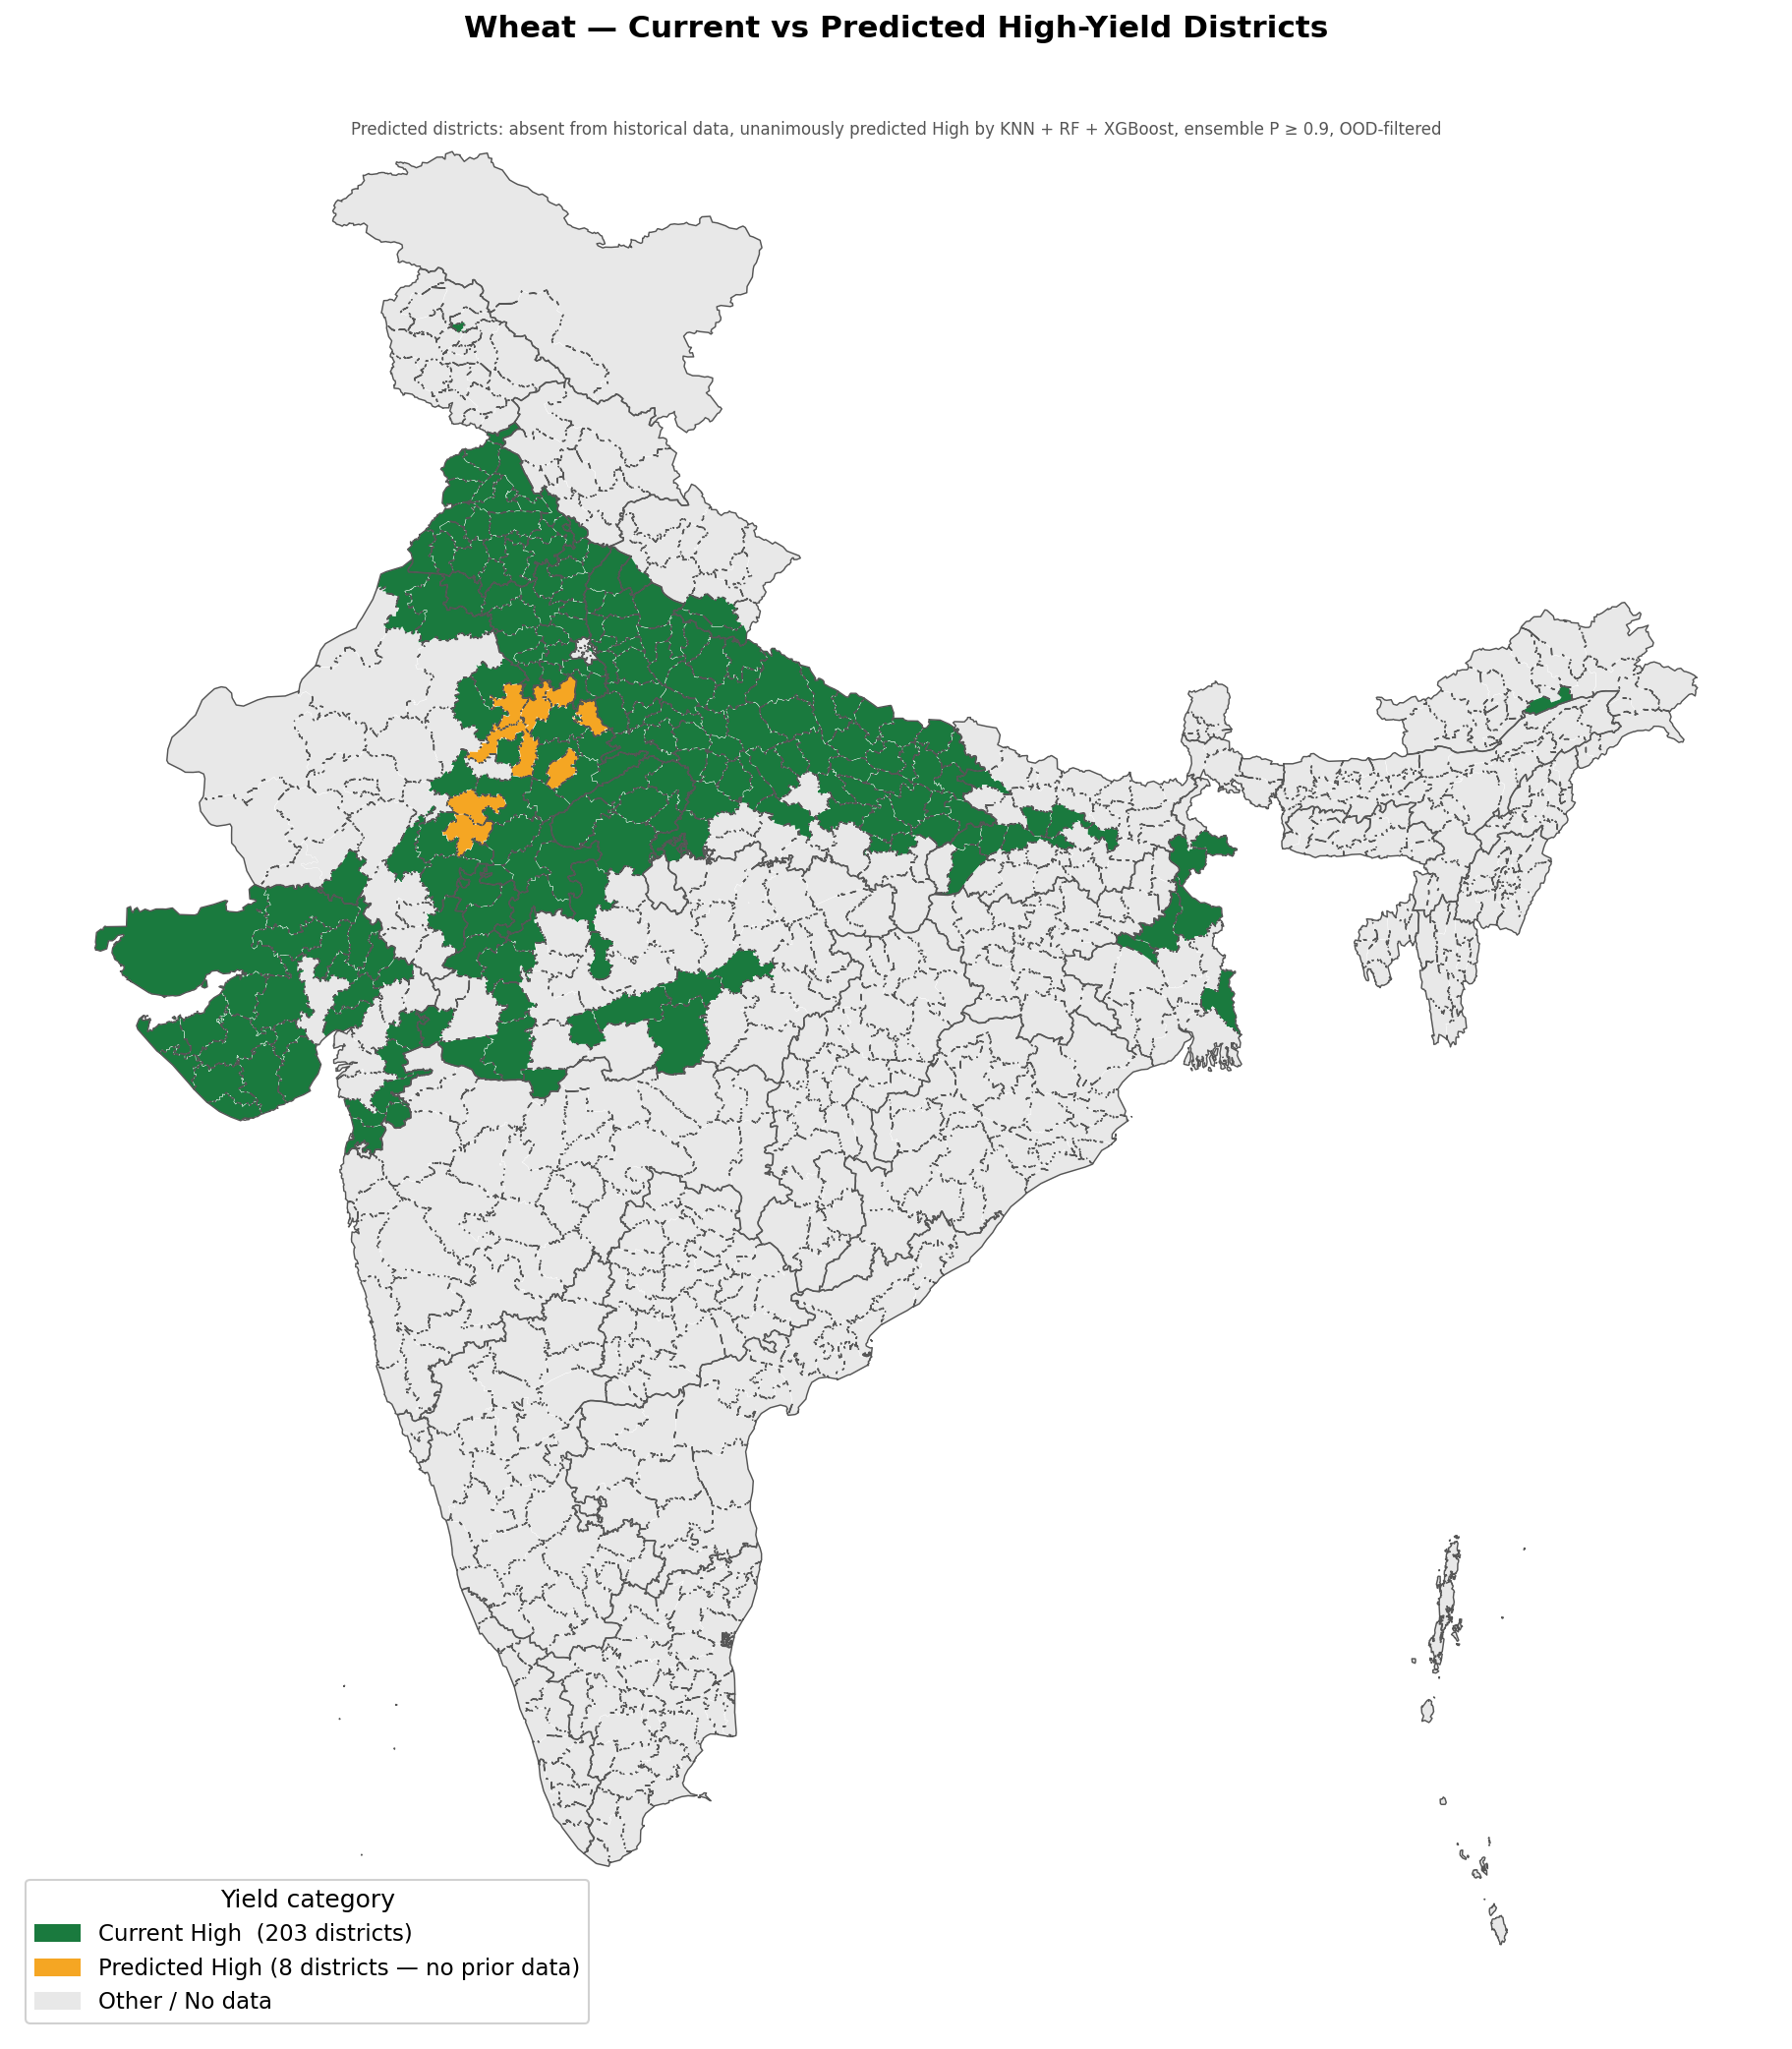


── Rapeseed And Mustard ──


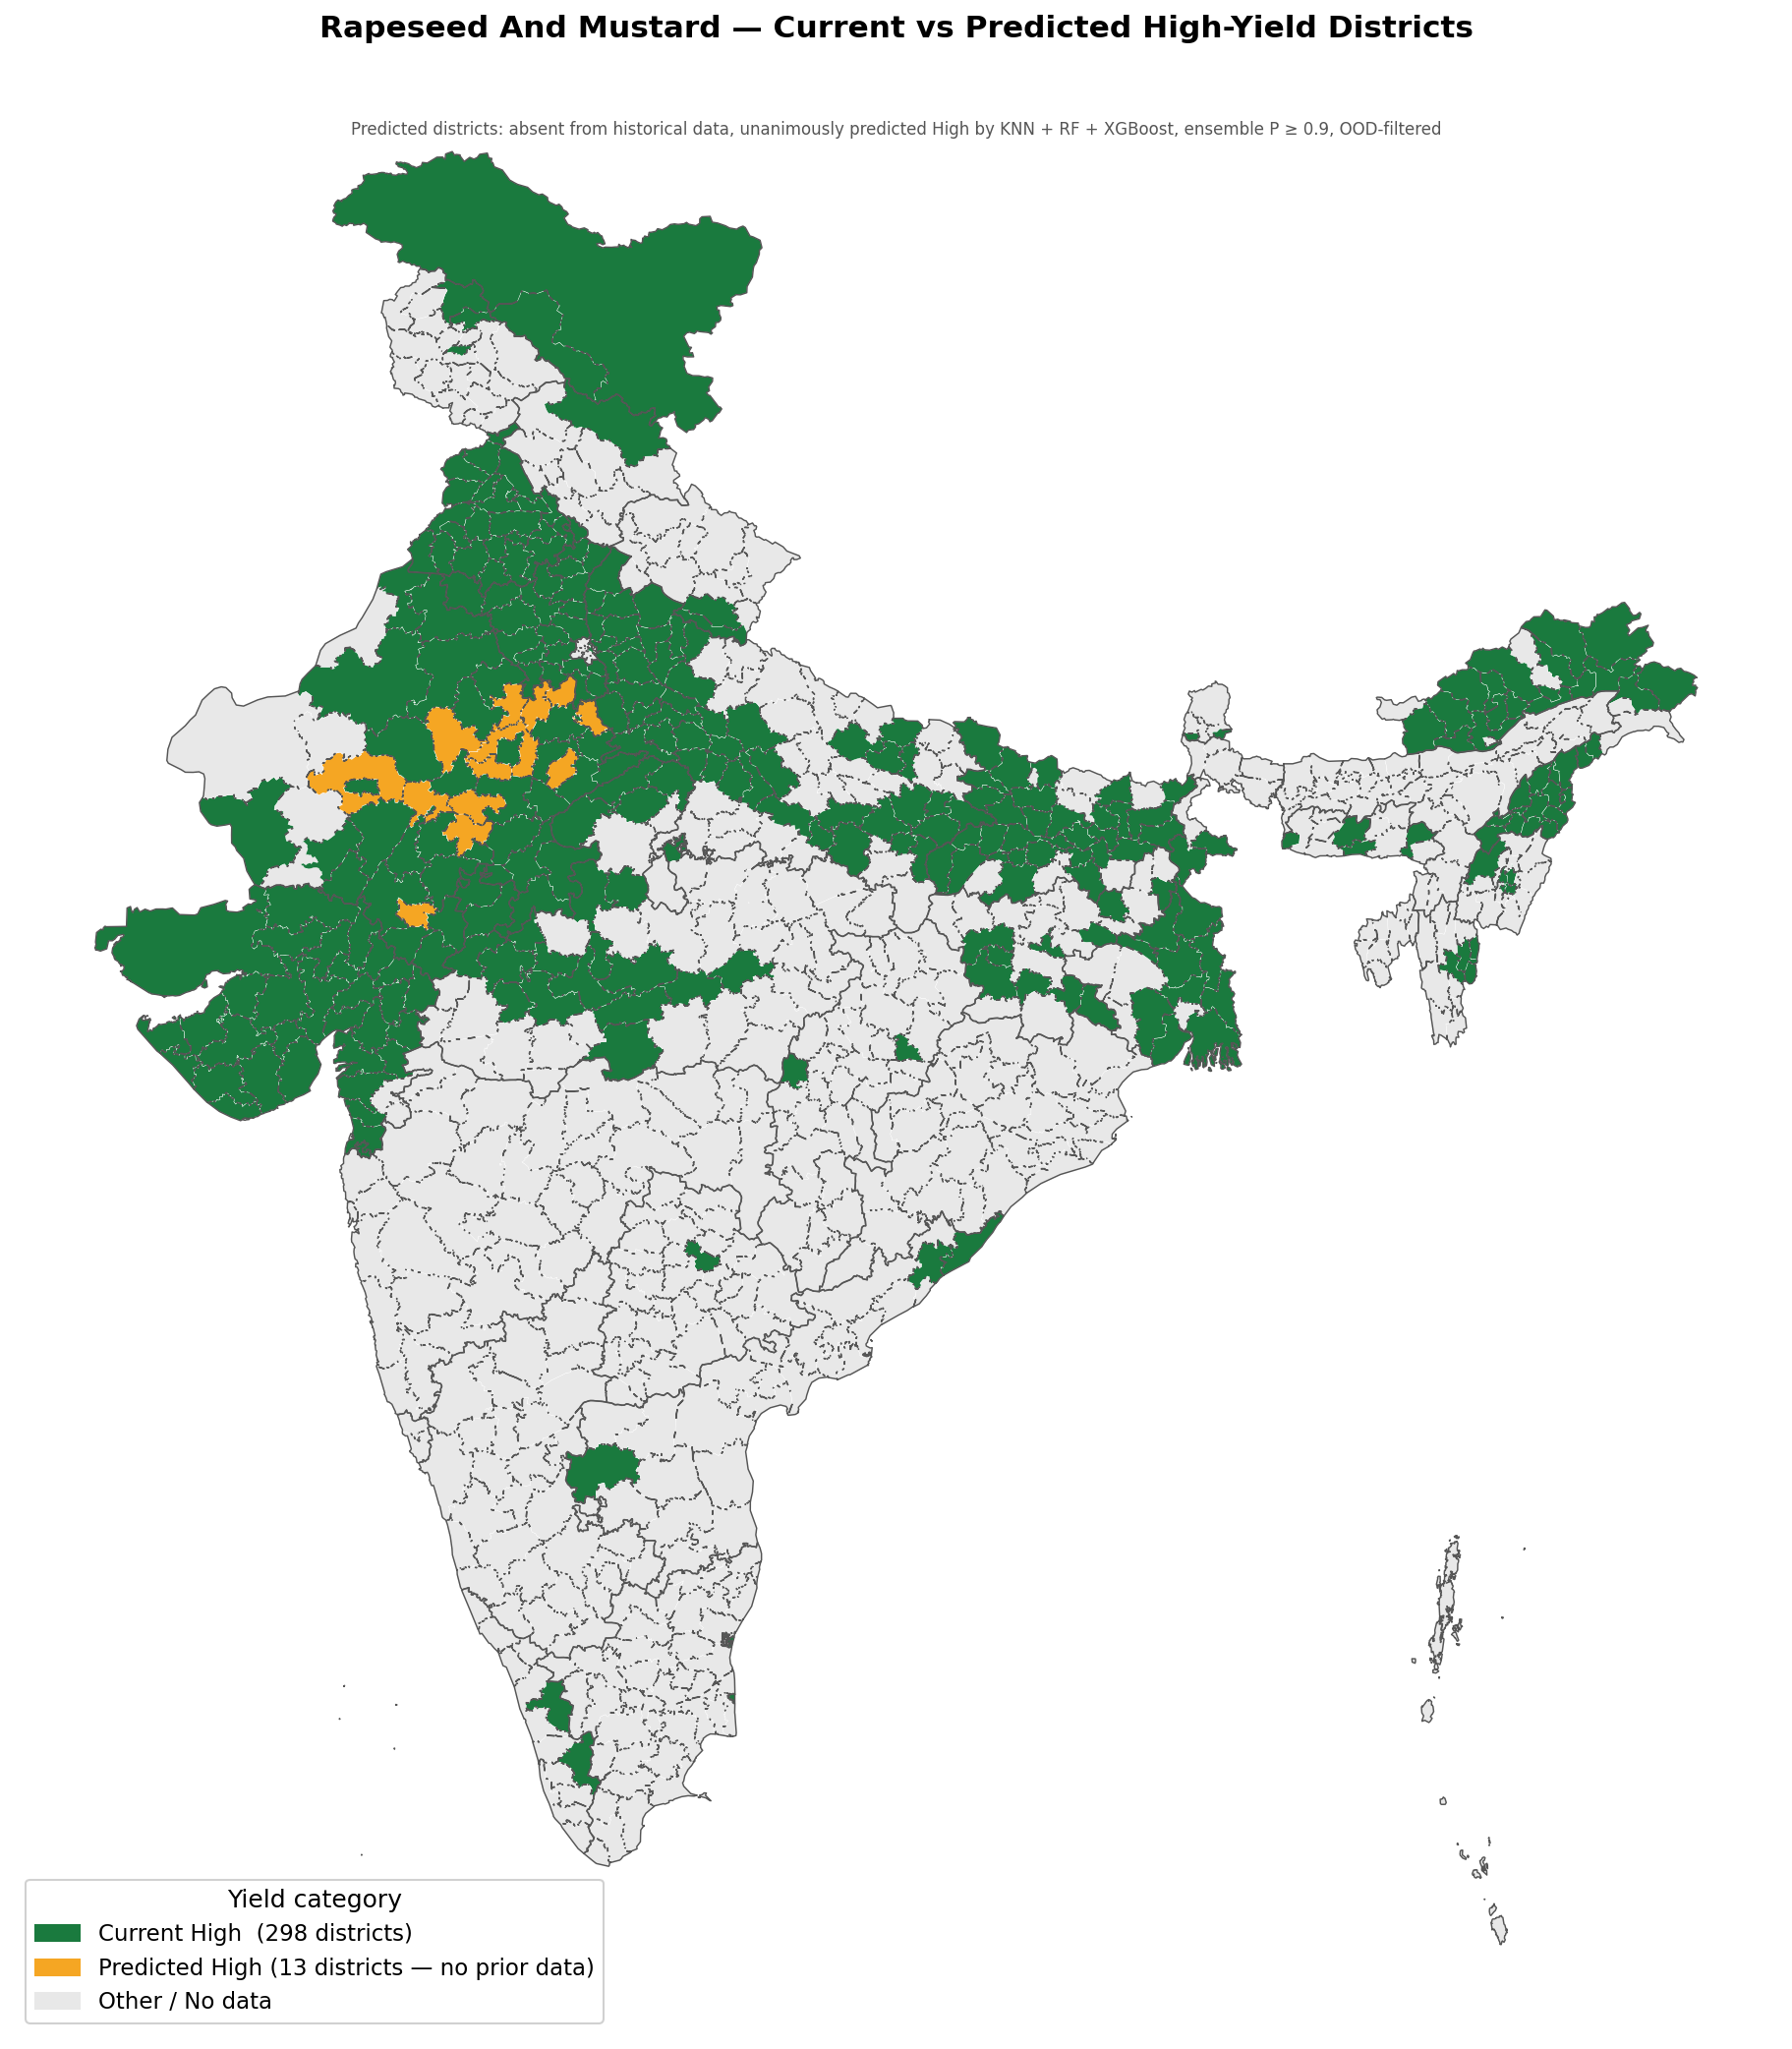


── Sugarcane ──


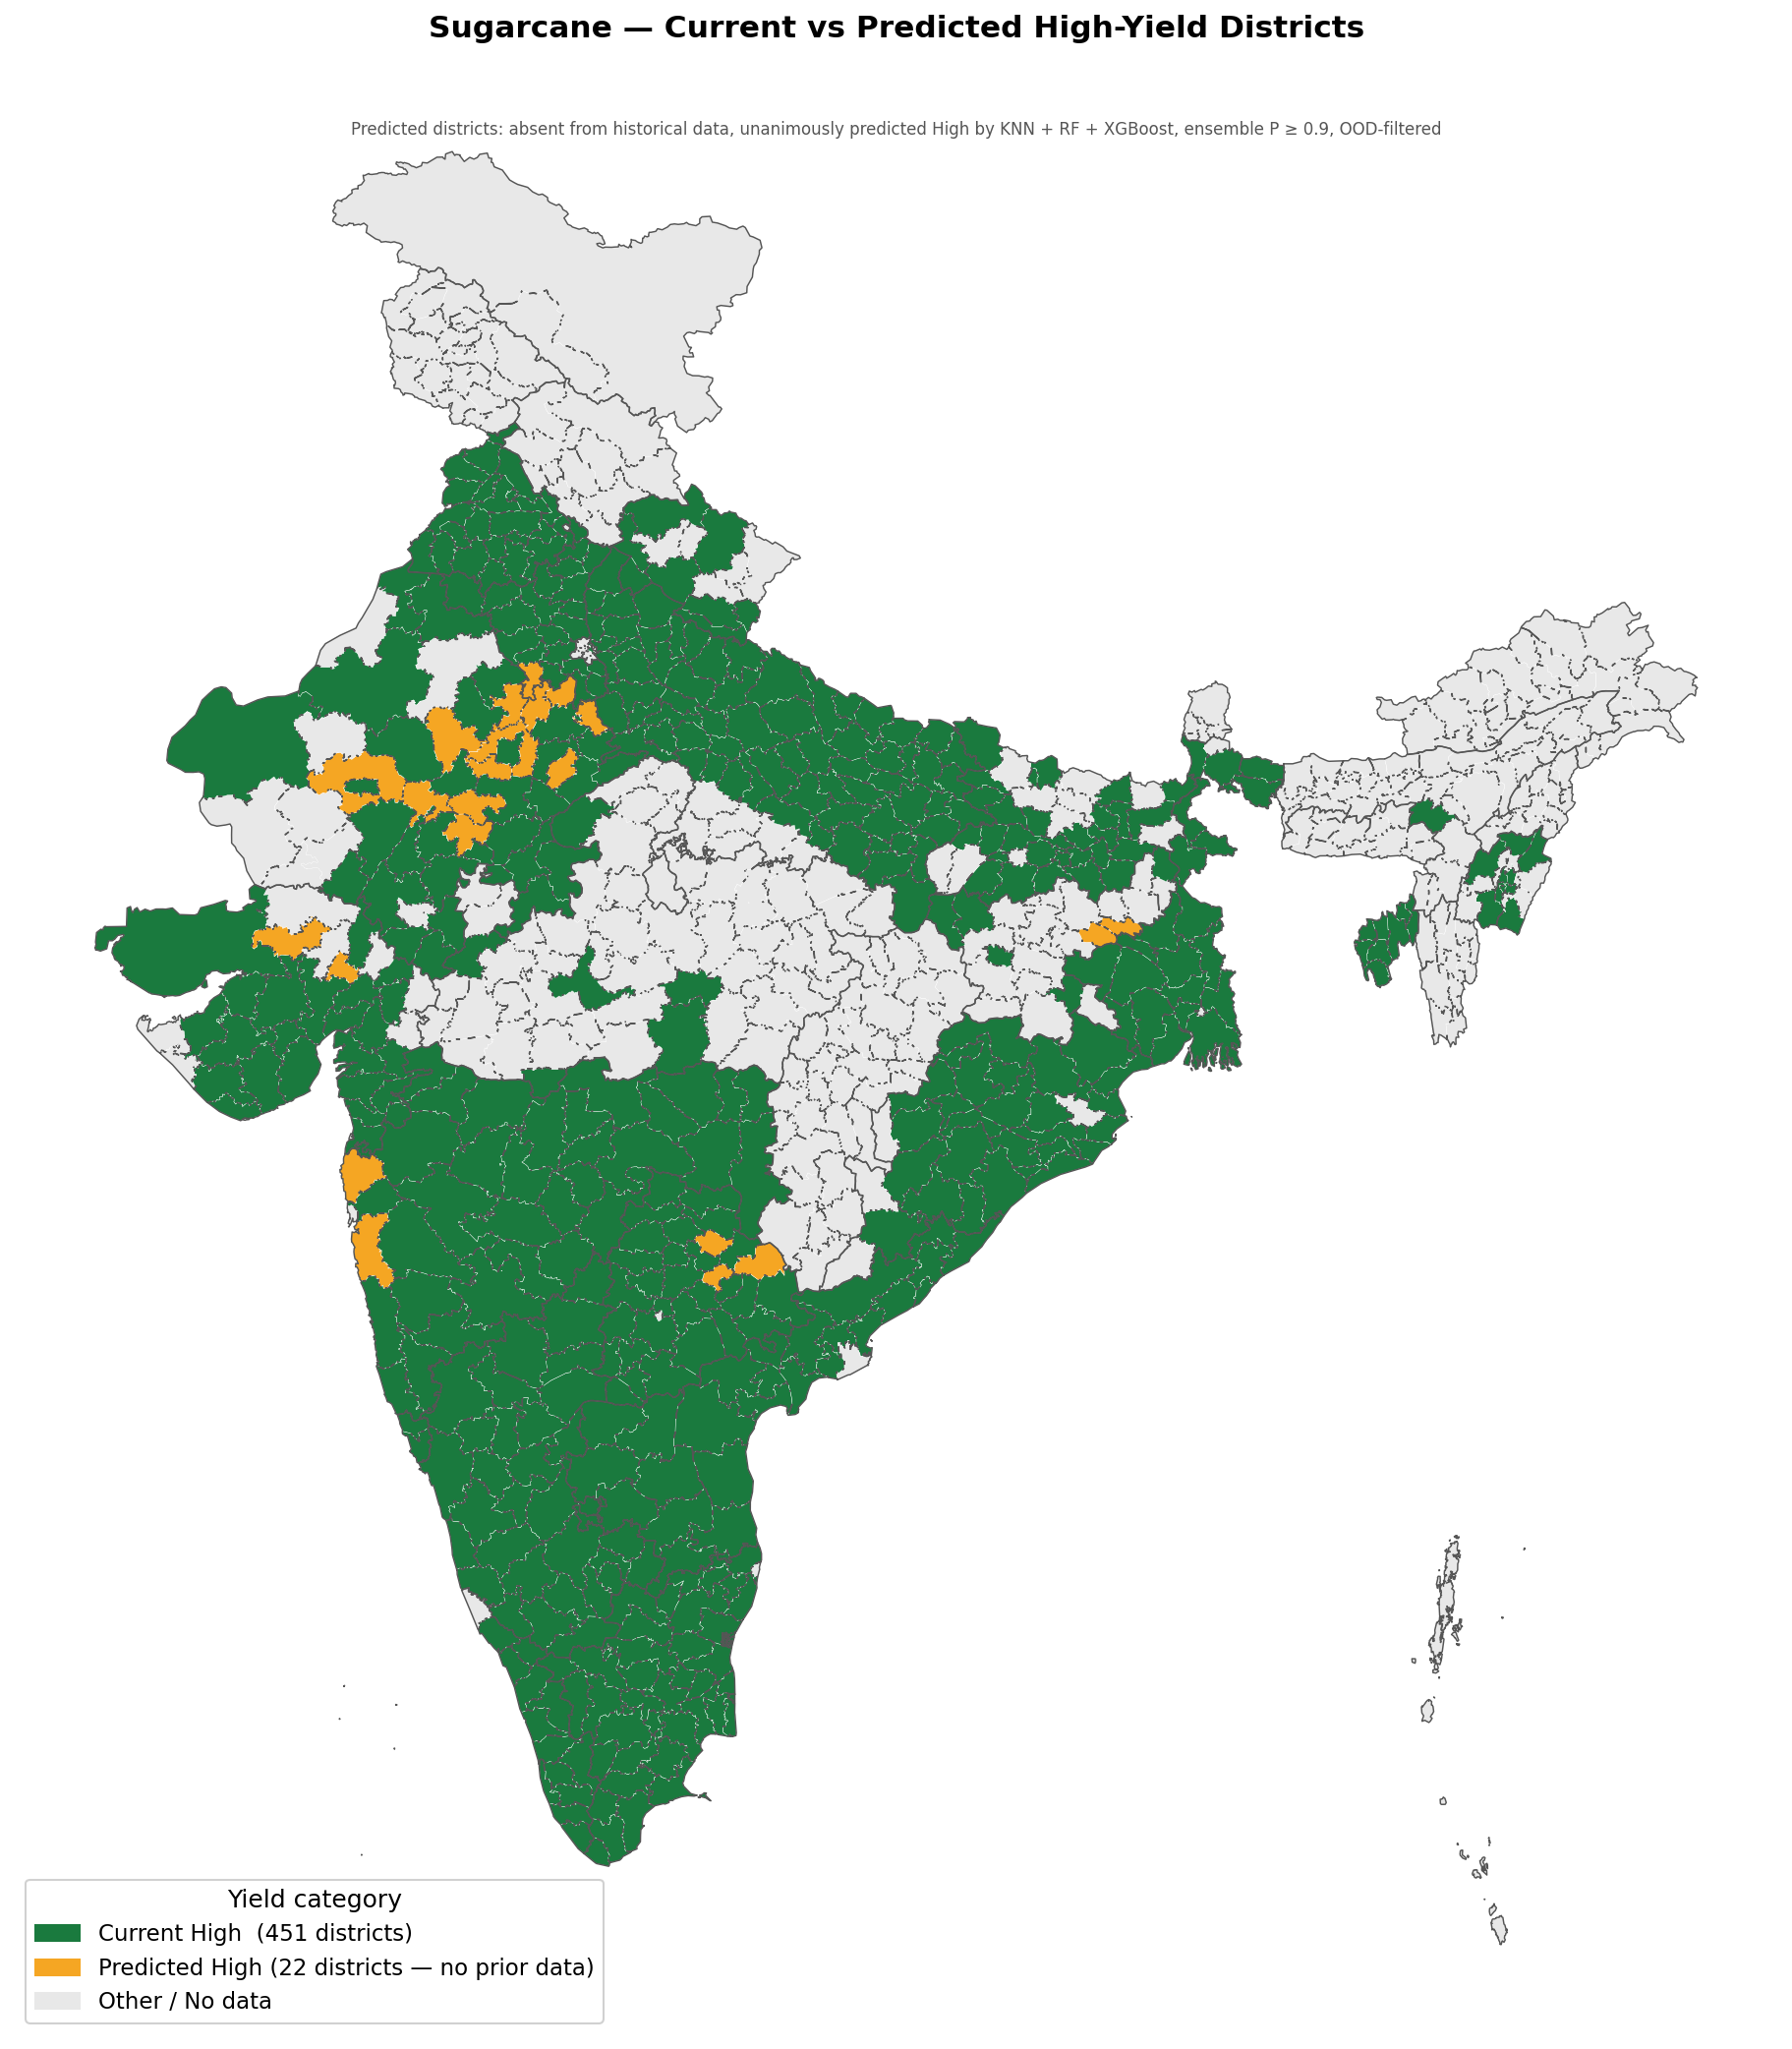


── Cotton ──


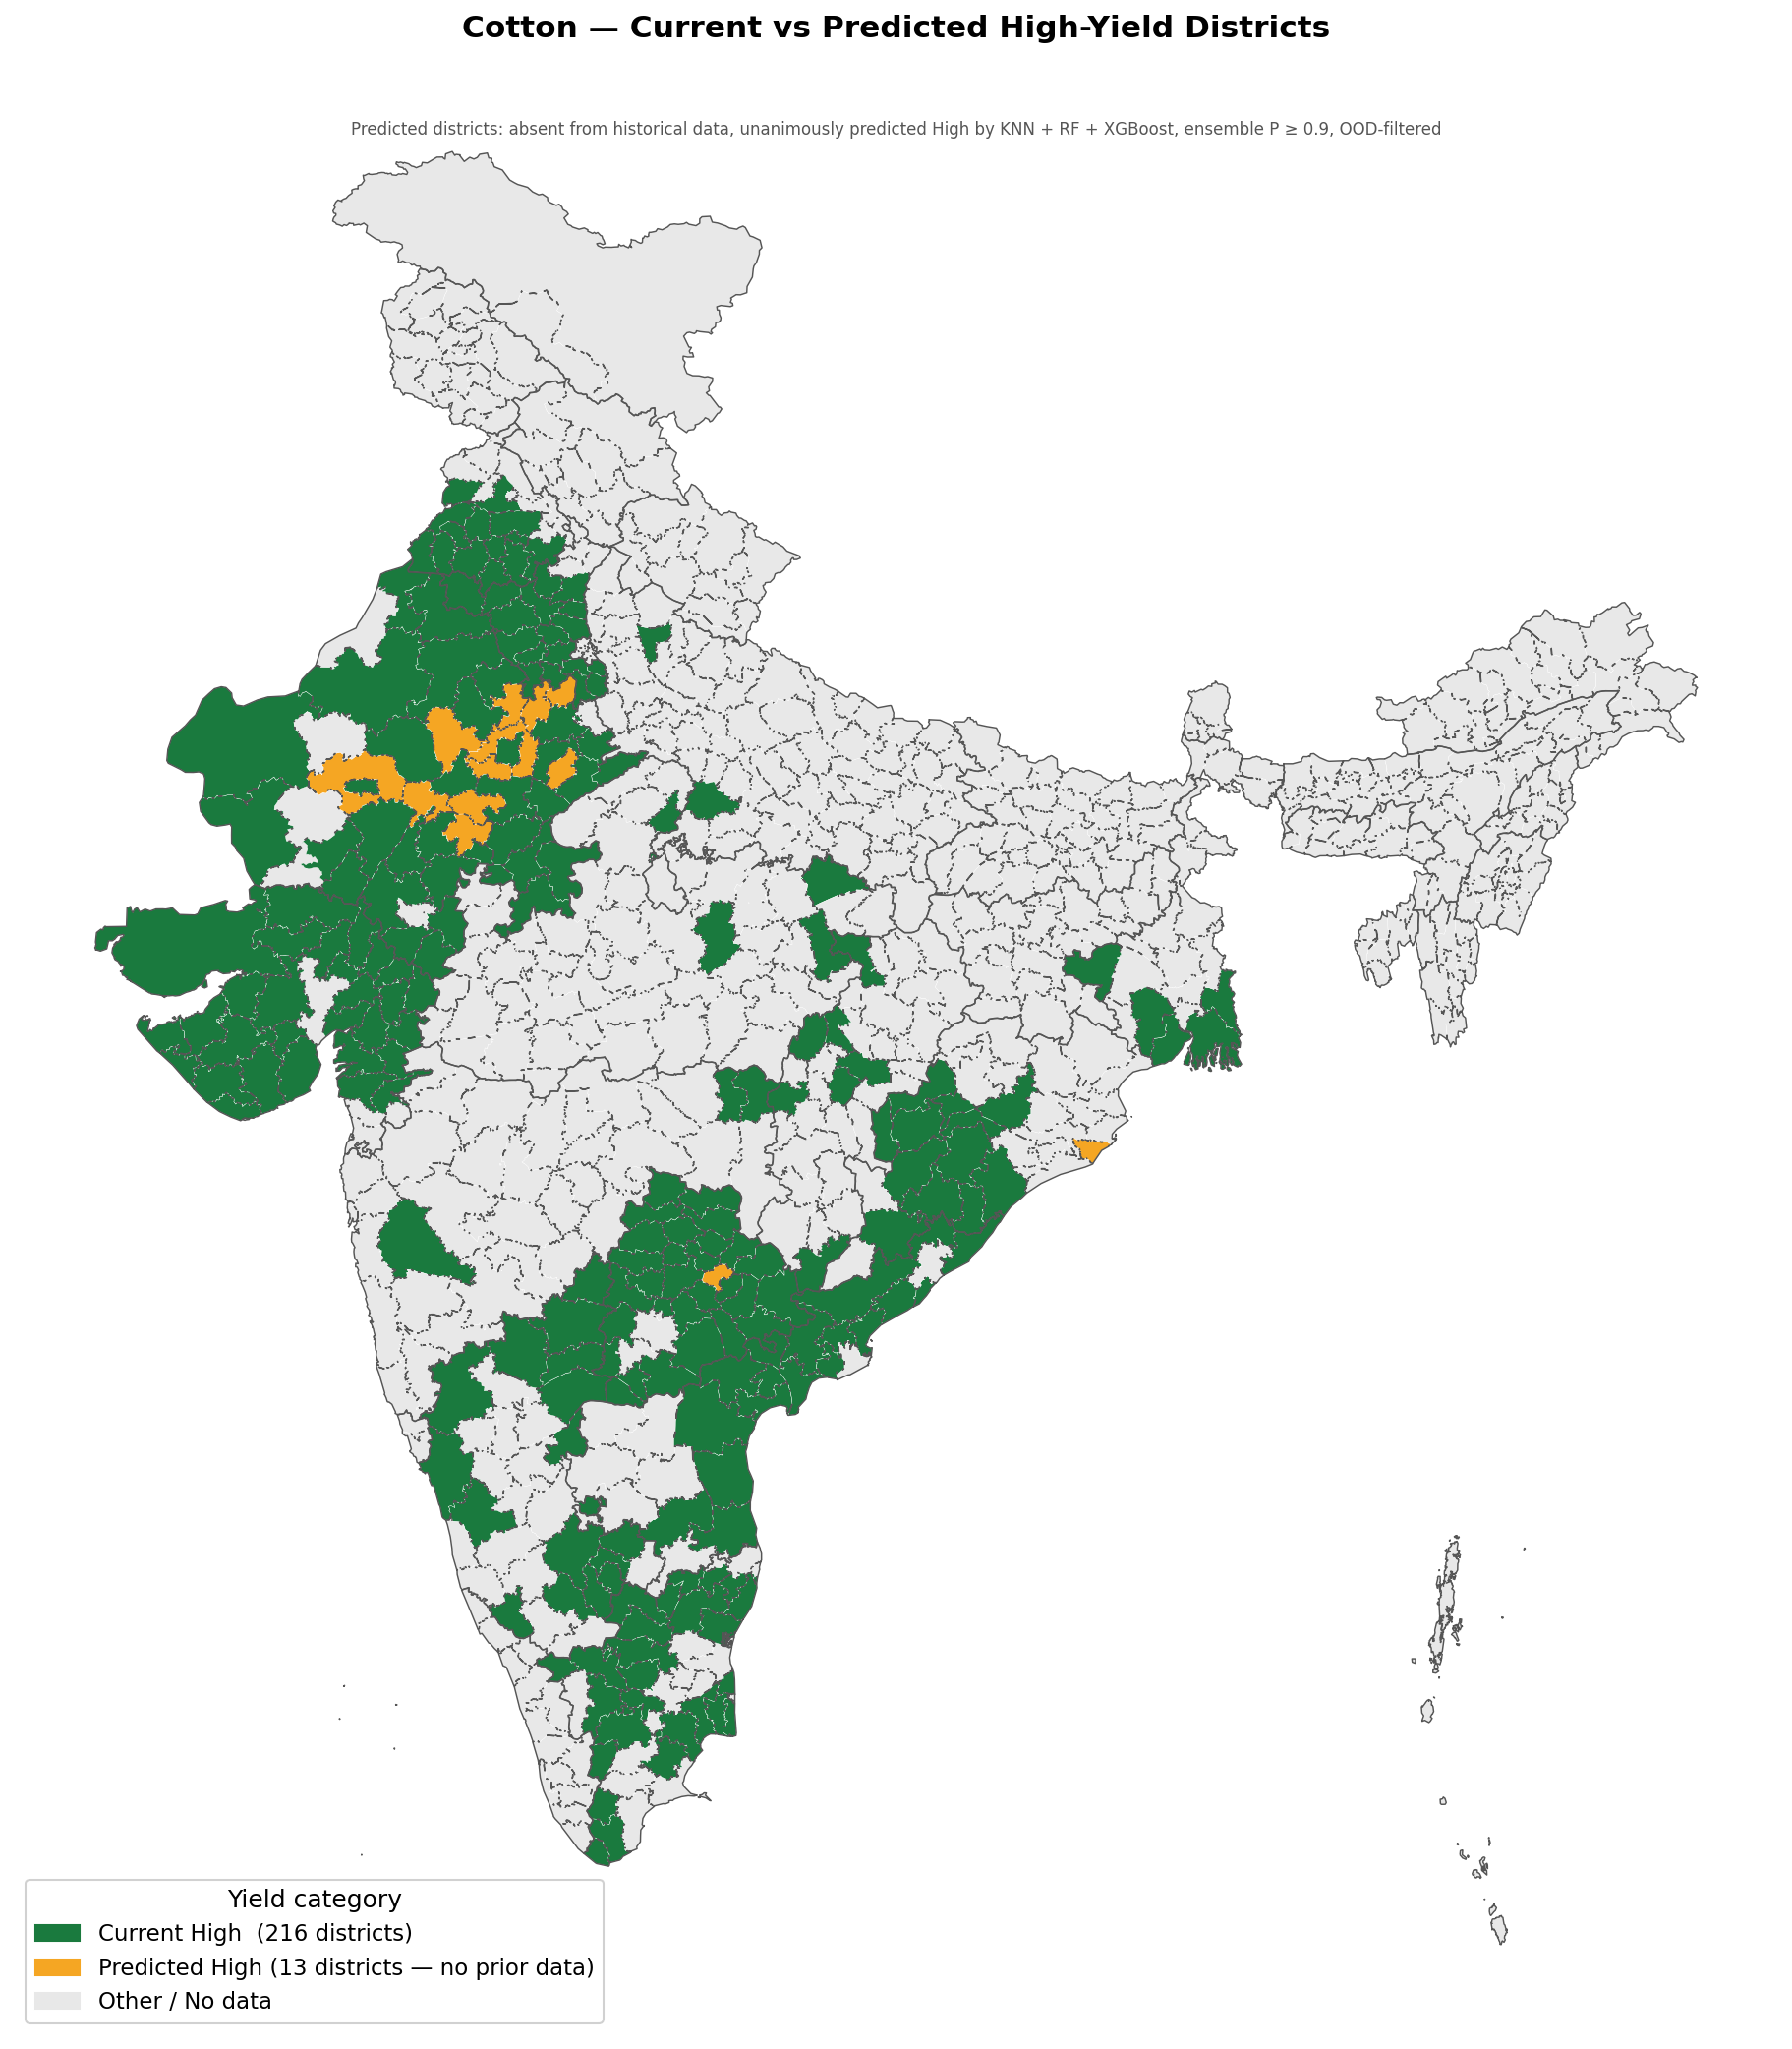


── Sunflower ──


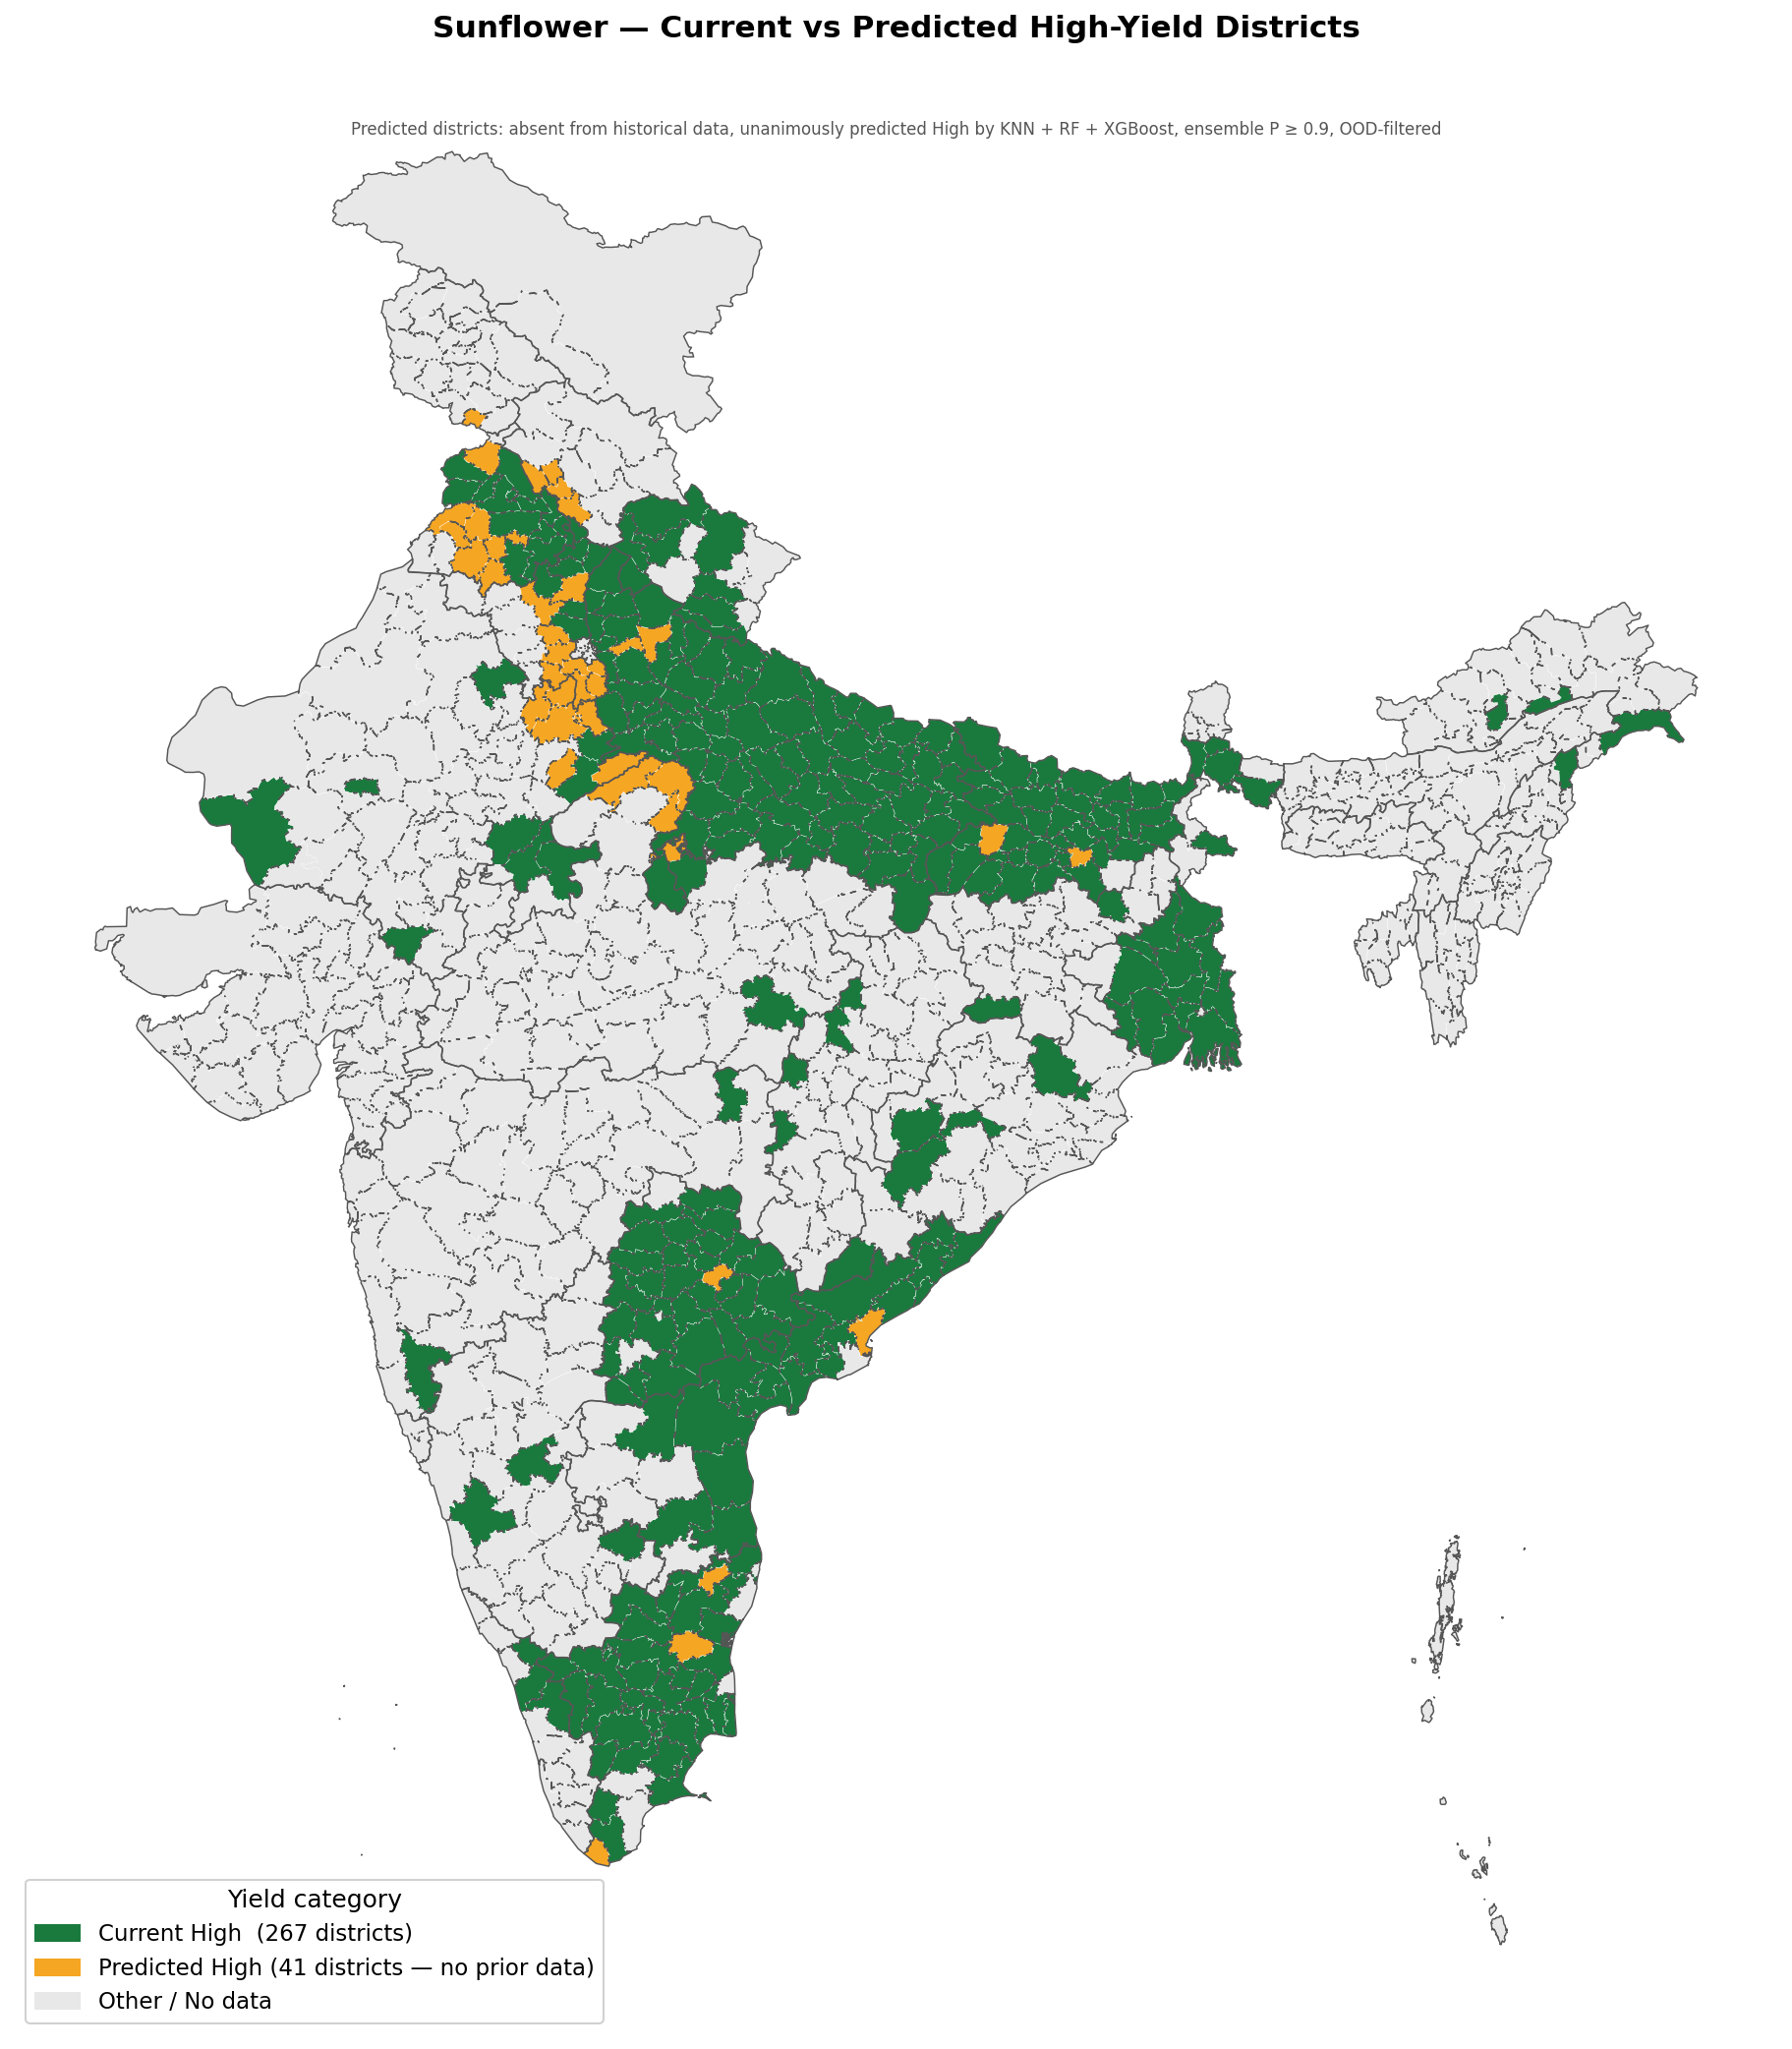

In [30]:
from IPython.display import Image, display

# Change this list to whichever crops you want to preview
PREVIEW_CROPS = [
    "wheat",
    "rapeseed_and_mustard",
    "sugarcane",
    "cotton",
    "sunflower",
]

for crop in PREVIEW_CROPS:
    path = f"choropleth_maps/{crop}.png"
    if os.path.exists(path):
        print(f"\n── {crop.replace('_',' ').title()} ──")
        display(Image(filename=path, width=900))
    else:
        print(f"  [{crop}] not found — either no predicted districts or crop was skipped.")

## 8 — Summary table

In [31]:
summary = pd.DataFrame(saved, columns=["crop", "current_high", "predicted_high", "map_path"])
summary["predicted_pct_of_current"] = (
    summary["predicted_high"] / summary["current_high"].replace(0, np.nan) * 100
).round(1)
summary = summary.sort_values("predicted_high", ascending=False).reset_index(drop=True)

summary.to_csv("choropleth_maps/map_summary.csv", index=False)
print("Summary saved → choropleth_maps/map_summary.csv\n")
summary[["crop", "current_high", "predicted_high", "predicted_pct_of_current"]]

Summary saved → choropleth_maps/map_summary.csv



,crop,current_high,predicted_high,predicted_pct_of_current
0,other_rabi_pulses,341,55,16.1
1,sunflower,267,41,15.4
2,horse_gram,107,33,30.8
3,mesta,150,32,21.3
4,potato,238,32,13.4
5,coriander,86,29,33.7
6,turmeric,178,28,15.7
7,safflower,117,25,21.4
8,other_cereals,101,25,24.8
9,banana,235,24,10.2
